# Model in this notebook

We solve a one-period sovereign debt model with a lender of last resort (LOLR). The state is $(b,\ell,g,\epsilon)$, where $b$ is private debt and $\ell$ is LOLR debt. The government chooses next-period private debt $b'$ (via issuance $n$) and LOLR borrowing $\ell'$ (via issuance $n_\ell$). The sovereign cannot default on the LOLR, which charges $R_\ell$ and imposes borrowing limits in repayment and default.

**Repayment value:**

$$
v^{nd}(b,\ell,g,\epsilon)=\max_{c,n,n_\ell}\left\{ \frac{c^{1-\gamma}}{1-\gamma} + \beta g^{1-\gamma} E\left[\max\{v^{nd}(b',\ell',g',\epsilon'), v^{d}(b',\ell',g',\epsilon')\} \mid g\right] \right\}
$$

$$
\begin{aligned}
&c + b + \ell = y + n + n_\ell,\quad y = g e^{\sigma\epsilon},\\
&g b' = R(n,\ell',g) n,\\
&g \ell' = R_\ell^{nd} n_\ell,\quad \ell' \le \bar{\ell}_{nd}.
\end{aligned}
$$

**Default value:**

$$
v^{d}(b,\ell,g,\epsilon)=\max_{c,n_\ell}\left\{ \frac{c^{1-\gamma}}{1-\gamma} + \beta g^{1-\gamma} E\left[\theta v^{d}(b',\ell',g',\epsilon') + (1-\theta)\max\{v^{nd}(\kappa b',\ell',g',\epsilon'), v^{d}(b',\ell',g',\epsilon')\} \mid g\right] \right\}
$$

$$
\begin{aligned}
&c + \ell = \phi(g) y + n_\ell,\quad y = g e^{\sigma\epsilon},\\
&g b' = b,\\
&g \ell' = R_\ell^{d} n_\ell,\quad \ell' \le \bar{\ell}_{d}.
\end{aligned}
$$

**Schedule and prices:**

$$
1 = \frac{R(n,\ell',g)}{1+r^*} E\left[Q(b',\ell',g',\epsilon')\mid g\right],\quad g b' = R(n,\ell',g) n.
$$

$$
Q(b,\ell,g,\epsilon) = (1-d) + d X,
$$

$$
X(b,\ell,g,\epsilon) = \frac{1}{1+r^*} E\left[(1-e)X(b',\ell'(h),g',\epsilon') + e\,\kappa Q(\kappa b',\ell'(h),g',\epsilon') \mid g\right].
$$


In [34]:
using LinearAlgebra, Statistics
include("src/structs_lolr.jl")
include("src/utils_lolr.jl")
include("src/solver_lolr.jl")
include("src/simulation_lolr.jl")

Threads.nthreads()

8

In [35]:
# Initialize model with default parameters and grids
model = init_model()


Model(1000, 100, 2, 10, -0.05, 1.0, 0.0, 0.02018461538461538, [-0.05, -0.048948948948948946, -0.0478978978978979, -0.04684684684684685, -0.0457957957957958, -0.04474474474474475, -0.04369369369369369, -0.04264264264264264, -0.04159159159159159, -0.04054054054054054  …  0.9905405405405405, 0.9915915915915916, 0.9926426426426427, 0.9936936936936936, 0.9947447447447447, 0.9957957957957958, 0.9968468468468469, 0.9978978978978978, 0.9989489489489489, 1.0], [0.0, 0.00020388500388500384, 0.0004077700077700077, 0.0006116550116550115, 0.0008155400155400154, 0.0010194250194250191, 0.001223310023310023, 0.0014271950271950269, 0.0016310800310800307, 0.0018349650349650346  …  0.018349650349650345, 0.01855353535353535, 0.018757420357420354, 0.01896130536130536, 0.019165190365190363, 0.019369075369075367, 0.019572960372960368, 0.019776845376845372, 0.019980730380730376, 0.02018461538461538], [0.96, 1.04], [-2.5, -1.9444444444444444, -1.3888888888888888, -0.8333333333333334, -0.2777777777777778, 0.277

In [ ]:
sol = solve_model(model)
mean(sol.d)


.

In [ ]:
# Diagnostics: iteration counts, errors, and per-iteration timing
println("Outer iterations: ", sol.outer_iters)
println("Final outer error: ", sol.outer_errs[end])

for i in 1:sol.outer_iters
    println("iter=", i,
        ", vnd_err=", sol.outer_errs[i],
        ", vd_err=", sol.vd_errs[i],
        ", x_err=", sol.x_errs[i],
        ", vd_iters=", sol.vd_iters[i],
        ", x_iters=", sol.x_iters[i],
        ", time_s=", sol.outer_times[i])
end


In [ ]:
# sol = solve_model(model; sol = sol)    # reuse vnd/vd if non-empty
# mean(sol.d)

In [ ]:
using Plots
using Measures
b = model.b
l = model.l
g = model.g
eps = model.eps

e_idx = Int(cld(model.Ne, 2))
l_idx = Int(cld(model.Nl, 2))
lp_idx = l_idx
b_idx = Int(cld(model.Nb, 2))

l_val = round(l[l_idx], digits = 3)
lp_val = round(l[lp_idx], digits = 3)
bp_val = round(b[b_idx], digits = 3)

p1 = plot(title = "Policy b' (mid shock, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "b'")
p2 = plot(title = "Policy l' (mid shock, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "l'")
p3 = plot(title = "Default decision (mid shock, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "default")
p4 = plot(title = "Bond price Q (mid shock, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "Q")
p5 = plot(title = "Schedule R(n,g) at l'=$(lp_val)", titlefontsize = 9, xlabel = "n", ylabel = "R")
p6 = plot(title = "Schedule R(b',g) at l'=$(lp_val)", titlefontsize = 9, xlabel = "b'", ylabel = "R(n,g)")
p7 = plot(title = "Schedule R(l',g) at b'=$(bp_val)", titlefontsize = 9, xlabel = "l'", ylabel = "R(n,g)")
p8 = plot(title = "Policy l' in default (mid shock, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "l'")
p9 = plot(title = "Default decision vs l (mid shock, b=$(bp_val))", titlefontsize = 9, xlabel = "l", ylabel = "default")
p10 = plot(title = "Bond price Q vs l (mid shock, b=$(bp_val))", titlefontsize = 9, xlabel = "l", ylabel = "Q")

for gi in 1:model.Ng
    bprime_policy = b[sol.b_policy_idx[:, l_idx, gi, e_idx]]
    lprime_policy = l[sol.l_policy_idx[:, l_idx, gi, e_idx]]
    lprime_policy_d = l[sol.l_policy_idx_d[:, l_idx, gi, e_idx]]
    plot!(p1, b, bprime_policy, label = "g=$(g[gi])")
    plot!(p2, b, lprime_policy, label = "g=$(g[gi])")
    plot!(p3, b, Float64.(sol.d[:, l_idx, gi, e_idx]), label = "g=$(g[gi])")
    plot!(p4, b, sol.Q[:, l_idx, gi, e_idx], label = "g=$(g[gi])")
    plot!(p5, sol.n[:, lp_idx, gi], sol.R[:, lp_idx, gi], label = "g=$(g[gi])")
    plot!(p6, b, sol.R[:, lp_idx, gi], label = "g=$(g[gi])")
    plot!(p7, l, sol.R[b_idx, :, gi], label = "g=$(g[gi])")
    plot!(p8, b, lprime_policy_d, label = "g=$(g[gi])")
    plot!(p9, l, Float64.(sol.d[b_idx, :, gi, e_idx]), label = "g=$(g[gi])")
    plot!(p10, l, sol.Q[b_idx, :, gi, e_idx], label = "g=$(g[gi])")
end
plot(p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, layout = (5, 2), size = (1500, 1800), left_margin = 8mm, right_margin = 8mm, top_margin = 8mm, bottom_margin = 12mm)


In [ ]:
gi = 1
li = 1
st = 1 #1550
en = 500
plot(sol.n[st:en, li, gi], sol.R[st:en, li, gi], label = "g=$(g[gi])", seriestype=:scatter)

In [ ]:
st = 1 #1550
en = 500
plot(b[st:en],sol.n[st:en, li, gi] , label="g=0.96", xlabel="b'", ylabel="n", seriestype=:scatter)


In [ ]:
# Simulation
b0_idx = 1  # pick a savings grid point by index
sim = simulate(model, sol; T = 200_000, b0_idx = b0_idx, seed = 1234)


In [ ]:
# Moments
stats = summarize_simulation(sim, model; burnin = 10_000, nbins = 1000)

println("Default rate (episodes / periods): ", stats.default_rate)
println("Mean debt-to-GDP: ", stats.mean_b_to_gdp)
println("Mean issuance-to-GDP: ", stats.mean_n_to_gdp)
println("Mean credit spread (non-default): ", stats.mean_credit_spread, " (N=", stats.credit_spread_obs, ")")
println("Share at b_min: ", stats.share_b_min, ", share at b_max: ", stats.share_b_max)

stats.hist_edges
stats.hist_counts


In [ ]:
# Histogram of debt (b)
edges = stats.hist_edges
counts = stats.hist_counts
mid = 0.5 .* (edges[1:end-1] .+ edges[2:end])
bar(mid, counts; xlabel = "b", ylabel = "count", legend = false, title = "Debt histogram")


In [ ]:
plot(sim.b)

## check run-time

In [ ]:
fmtbytes(x) = Base.format_bytes(x)
allocs(t) = t.gcstats.malloc + t.gcstats.realloc + t.gcstats.poolalloc + t.gcstats.bigalloc

# --- setup (mirrors solve_model) ---
model = init_model()

b = model.b
l = model.l
g = model.g
eps = model.eps

Nb, Nl, Ng, Ne = model.Nb, model.Nl, model.Ng, model.Ne

y = reshape(g, Ng, 1) .* exp.(model.sigma_eps .* reshape(eps, 1, Ne))
g_beta = model.beta .* (g .^ (1 - model.gamma))

bprime = b ./ reshape(g, 1, Ng)
bprime_idx = nearest_index(b, bprime)
kbprime_idx = nearest_index(b, model.kappa .* bprime)
b0_idx = findmin(abs.(b))[2]
l0_idx = findmin(abs.(l))[2]

base = u(y, model.gamma) ./ (1 - model.beta)
vnd = repeat(reshape(base, 1, 1, Ng, Ne), Nb, Nl, 1, 1)
vd = copy(vnd .- 1.0)
X = ones(Float64, Nb, Nl, Ng, Ne)

d = falses(Nb, Nl, Ng, Ne)
e = trues(Nb, Nl, Ng, Ne)

println("---- timings (first run includes compilation) ----")

t = @timed _solve_vd!(vd, vnd, model, y, g_beta, bprime_idx, kbprime_idx, l, l0_idx)
(err_vd, it_vd, l_policy_idx_d) = t.value
println("solve_vd!: time=$(t.time)s, allocs=$(allocs(t)), bytes=$(fmtbytes(t.bytes))")

d = vnd .< vd
e = .!d

t = @timed _solve_prices!(X, d, e, model, bprime_idx, kbprime_idx, l_policy_idx_d)
(Q, err_x, it_x) = t.value
println("solve_prices!: time=$(t.time)s, allocs=$(allocs(t)), bytes=$(fmtbytes(t.bytes))")

t = @timed _compute_schedule(b, l, g, model, Q, d)
(QE, R, n, pdefault) = t.value
println("compute_schedule!: time=$(t.time)s, allocs=$(allocs(t)), bytes=$(fmtbytes(t.bytes))")

t = @timed _update_vnd!(vnd, vd, model, b, l, y, g_beta, n, pdefault, b0_idx, l0_idx)
err_update = t.value
println("update_vnd!: time=$(t.time)s, allocs=$(allocs(t)), bytes=$(fmtbytes(t.bytes))")

t = @timed _compute_policy_idx(model, b, l, y, g_beta, n, pdefault, vnd, vd, b0_idx, l0_idx)
(bpol, lpol) = t.value
println("compute_policy_idx!: time=$(t.time)s, allocs=$(allocs(t)), bytes=$(fmtbytes(t.bytes))")


## Solves for different $\Delta$ and $\sigma$

In [ ]:
using Printf
include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))

Δ_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]
spreads = [0.04, 0.06, 0.08, 0.10]  # r* + spread (net); gross R_l = 1 + r* + spread

rstar = Model().rstar
results = Dict{Tuple{Float64, Float64}, Any}()

results_dir = joinpath(pwd(), "results")
mkpath(results_dir)

for spr in spreads
    prev_sol_same_spr = nothing
    for Δ in Δ_vals
        R_l = 1 + rstar + spr
        model = init_model(Model(; Δ_nd = Δ, Δ_d = Δ, R_l_nd = R_l, R_l_d = R_l))

        fname = @sprintf("sol_Delta=%0.2f_spread=%0.2f.jld2", Δ, spr)
        fpath = joinpath(results_dir, fname)

        guess_sol = nothing
        if isfile(fpath)
            loaded = load_jld2_file(fpath)
            if loaded.model !== nothing && loaded.sol !== nothing
                guess_sol = loaded.sol
                println("Found existing file for Δ=", Δ, ", spread=", spr, " -> using saved solution as initial guess")
            else
                println("Found existing file for Δ=", Δ, ", spread=", spr, " but no model/sol payload -> cold start")
            end
        elseif prev_sol_same_spr !== nothing
            guess_sol = prev_sol_same_spr
            println("No existing file for Δ=", Δ, ", spread=", spr, " -> using previous Δ at same spread as initial guess")
        else
            println("No existing file for Δ=", Δ, ", spread=", spr, " -> cold start")
        end

        println("Running Δ=", Δ, ", spread=", spr, " (R_l=", R_l, ")")
        sol = guess_sol === nothing ? solve_model(model) : solve_model(model; sol = guess_sol)

        results[(Δ, spr)] = (model = model, sol = sol)
        save_jld2_file(fpath; model = model, sol = sol, metadata = (Delta = Δ, spread = spr, format = "lolr_model_solution_v1",))
        println("saved ", fpath)

        prev_sol_same_spr = sol
    end
end

# save_jld2_file(joinpath(results_dir, "all_solutions.jld2"); data = results, metadata = (format = "lolr_all_solutions_v1",))


## Compare with baseline model

In [ ]:
using Measures
using Printf, Statistics, Plots

include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))


# ---- Compare Δ=0 LOLR vs baseline model (visual) ----
Δ = 0.0
spr = 0.04

results_dir = joinpath(pwd(), "results")
fname = @sprintf("sol_Delta=%0.2f_spread=%0.2f.jld2", Δ, spr)
fpath = joinpath(results_dir, fname)

if isfile(fpath)
    loaded = load_jld2_file(fpath)
    model_l = loaded.model
    sol_l = loaded.sol
else
    error("LOLR solution not found at $(fpath). Run the Δ=0 grid first.")
end

base_path = normpath(joinpath(pwd(), "..", "1period", "results", "solution.jld2"))
if !isfile(base_path)
    error("Baseline solution not found at $(base_path). Save baseline results as JLD2 first.")
end

base_loaded = load_jld2_file(base_path)
if base_loaded.model === nothing || base_loaded.sol === nothing
    error("Baseline JLD2 file at $(base_path) must contain keys model and sol.")
end
base_model = base_loaded.model
base_sol = base_loaded.sol
base = (
    b = base_model.b,
    d = base_sol.d,
    Q = base_sol.Q,
    b_policy_idx = base_sol.b_policy_idx,
    Ne = base_model.Ne,
    Ng = base_model.Ng,
    g = base_model.g
)

# Mid shock, both growth states
e_idx_l = Int(cld(model_l.Ne, 2))
e_idx_b = Int(cld(base.Ne, 2))
l0_idx = findmin(abs.(model_l.l))[2]
b_idx = Int(cld(model_l.Nb, 2))
bp_val = round(model_l.b[b_idx], digits = 3)

# Color map for growth states (bad=blue, good=orange)
g_colors = Dict(1 => :lightskyblue, 2 => :orange)

function plot_panel(title_str, ybase, yl; xlabel="b", ylabel="")
    p = plot(title = title_str, titlefontsize = 9, xlabel = xlabel, ylabel = ylabel)
    for g_idx in 1:2
        plot!(p, base.b, ybase[g_idx], label = "baseline g=$(base.g[g_idx])",
            color = g_colors[g_idx], linestyle = :dash)
        plot!(p, model_l.b, yl[g_idx], label = "LOLR g=$(model_l.g[g_idx])",
            color = g_colors[g_idx], linestyle = :dot)
    end
    return p
end

function plot_panel_lolr(title_str, x, yl; xlabel="b", ylabel="")
    p = plot(title = title_str, titlefontsize = 9, xlabel = xlabel, ylabel = ylabel)
    for g_idx in 1:2
        plot!(p, x, yl[g_idx], label = "LOLR g=$(model_l.g[g_idx])",
            color = g_colors[g_idx], linestyle = :dot)
    end
    return p
end

# Prepare series for each g
bpol_base = Dict{Int, Vector{Float64}}()
d_base = Dict{Int, Vector{Float64}}()
q_base = Dict{Int, Vector{Float64}}()

bpol_l = Dict{Int, Vector{Float64}}()
d_l = Dict{Int, Vector{Float64}}()
q_l = Dict{Int, Vector{Float64}}()

lpol_l = Dict{Int, Vector{Float64}}()
lpol_l_d = Dict{Int, Vector{Float64}}()
r_l = Dict{Int, Vector{Float64}}()
d_l_l = Dict{Int, Vector{Float64}}()
q_l_l = Dict{Int, Vector{Float64}}()

for g_idx in 1:2
    bpol_base[g_idx] = base.b[base.b_policy_idx[:, g_idx, e_idx_b]]
    d_base[g_idx] = Float64.(base.d[:, g_idx, e_idx_b])
    q_base[g_idx] = base.Q[:, g_idx, e_idx_b]

    bpol_l[g_idx] = model_l.b[sol_l.b_policy_idx[:, l0_idx, g_idx, e_idx_l]]
    d_l[g_idx] = Float64.(sol_l.d[:, l0_idx, g_idx, e_idx_l])
    q_l[g_idx] = sol_l.Q[:, l0_idx, g_idx, e_idx_l]

    lpol_l[g_idx] = model_l.l[sol_l.l_policy_idx[:, l0_idx, g_idx, e_idx_l]]
    lpol_l_d[g_idx] = model_l.l[sol_l.l_policy_idx_d[:, l0_idx, g_idx, e_idx_l]]
    r_l[g_idx] = sol_l.R[b_idx, :, g_idx]
    d_l_l[g_idx] = Float64.(sol_l.d[b_idx, :, g_idx, e_idx_l])
    q_l_l[g_idx] = sol_l.Q[b_idx, :, g_idx, e_idx_l]
end

p1 = plot_panel("Policy b' (mid shock)", bpol_base, bpol_l; ylabel = "b'")
p2 = plot_panel("Default decision", d_base, d_l; ylabel = "default")
p3 = plot_panel("Bond price Q", q_base, q_l; ylabel = "Q")

p4 = plot_panel_lolr("Policy l' (mid shock)", model_l.b, lpol_l; ylabel = "l'")
p5 = plot_panel_lolr("Policy l' in default (mid shock)", model_l.b, lpol_l_d; ylabel = "l'")
p6 = plot_panel_lolr("Schedule R(l', g) at b'=$(bp_val)", model_l.l, r_l; xlabel = "l'", ylabel = "R")
p7 = plot_panel_lolr("Default decision vs l (mid shock, b=$(bp_val))", model_l.l, d_l_l; xlabel = "l", ylabel = "default")
p8 = plot_panel_lolr("Bond price Q vs l (mid shock, b=$(bp_val))", model_l.l, q_l_l; xlabel = "l", ylabel = "Q")

plot(p1, p2, p3, p4, p5, p6, p7, p8, layout = (4, 2), size = (1400, 1600), left_margin = 8mm, right_margin = 8mm, top_margin = 8mm, bottom_margin = 12mm)


## Depicting the policies for $\Delta$ and $\sigma$

In [ ]:
using Measures
using Printf, Plots

include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))


results_dir = joinpath(pwd(), "results")

# Set the grid to plot (must match saved filenames)
Δ_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]
spreads = [0.04, 0.06, 0.08, 0.10]  # r* + spread (net)

function plot_policies(model, sol; title_prefix="")
    b = model.b
    l = model.l
    g = model.g

    e_idx = Int(cld(model.Ne, 2))
    l_idx = 1 #Int(cld(model.Nl, 2))
    lp_idx = l_idx
    b_idx = Int(cld(model.Nb, 2))

    l_val = round(l[l_idx], digits = 3)
    lp_val = round(l[lp_idx], digits = 3)
    bp_val = round(b[b_idx], digits = 3)

    prefix = title_prefix == "" ? "" : "$(title_prefix) | "
    p1 = plot(title = "$(prefix)Policy b' (mid e, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "b'")
    p2 = plot(title = "$(prefix)Policy l' (mid e, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "l'")
    p3 = plot(title = "$(prefix)Default decision (mid e, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "default")
    p4 = plot(title = "$(prefix)Bond price Q (mid e, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "Q")
    p5 = plot(title = "$(prefix)Sched. R(n,g) at l'=$(lp_val)", titlefontsize = 9, xlabel = "n", ylabel = "R")
    p6 = plot(title = "$(prefix)Sched. R(b',g) at l'=$(lp_val)", titlefontsize = 9, xlabel = "b'", ylabel = "R")
    p7 = plot(title = "$(prefix)Sched. R(l',g) at b'=$(bp_val)", titlefontsize = 9, xlabel = "l'", ylabel = "R")
    p8 = plot(title = "$(prefix)Policy l' in default (mid e, l=$(l_val))", titlefontsize = 9, xlabel = "b", ylabel = "l'")
    p9 = plot(title = "$(prefix)Default dec. vs l (mid e, b=$(bp_val))", titlefontsize = 9, xlabel = "l", ylabel = "default")
    p10 = plot(title = "$(prefix)Bond price Q vs l (mid e, b=$(bp_val))", titlefontsize = 9, xlabel = "l", ylabel = "Q")


    for gi in 1:model.Ng
        bprime_policy = b[sol.b_policy_idx[:, l_idx, gi, e_idx]]
        lprime_policy = l[sol.l_policy_idx[:, l_idx, gi, e_idx]]
        lprime_policy_d = l[sol.l_policy_idx_d[:, l_idx, gi, e_idx]]
        plot!(p1, b, bprime_policy, label = "g=$(g[gi])")
        plot!(p2, b, lprime_policy, label = "g=$(g[gi])")
        plot!(p3, b, Float64.(sol.d[:, l_idx, gi, e_idx]), label = "g=$(g[gi])")
        plot!(p4, b, sol.Q[:, l_idx, gi, e_idx], label = "g=$(g[gi])")
        plot!(p5, sol.n[:, lp_idx, gi], sol.R[:, lp_idx, gi], label = "g=$(g[gi])")
        plot!(p6, b, sol.R[:, lp_idx, gi], label = "g=$(g[gi])")
        plot!(p7, l, sol.R[b_idx, :, gi], label = "g=$(g[gi])")
        plot!(p8, b, lprime_policy_d, label = "g=$(g[gi])")
        plot!(p9, l, Float64.(sol.d[b_idx, :, gi, e_idx]), label = "g=$(g[gi])")
        plot!(p10, l, sol.Q[b_idx, :, gi, e_idx], label = "g=$(g[gi])")
    end
    return plot(p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, layout = (2, 5), size = (2100, 800), left_margin = 8mm, right_margin = 8mm, top_margin = 8mm, bottom_margin = 12mm)
end

for Δ in Δ_vals, spr in spreads
    fname = @sprintf("sol_Delta=%0.2f_spread=%0.2f.jld2", Δ, spr)
    fpath = joinpath(results_dir, fname)
    if !isfile(fpath)
        @warn "missing result file, skipping" fpath
        continue
    end
    data = load_jld2_file(fpath)
    model = data.model
    sol = data.sol
    println("Plotting Δ=", Δ, ", spread=", spr, ", file=", fpath)
    display(plot_policies(model, sol; title_prefix=@sprintf("Δ=%0.2f, σ=%0.2f", Δ, spr)))
end


Saved figure: /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_lolr/results/lolr_policies_by_delta_spread=0.06_gidx=1.png


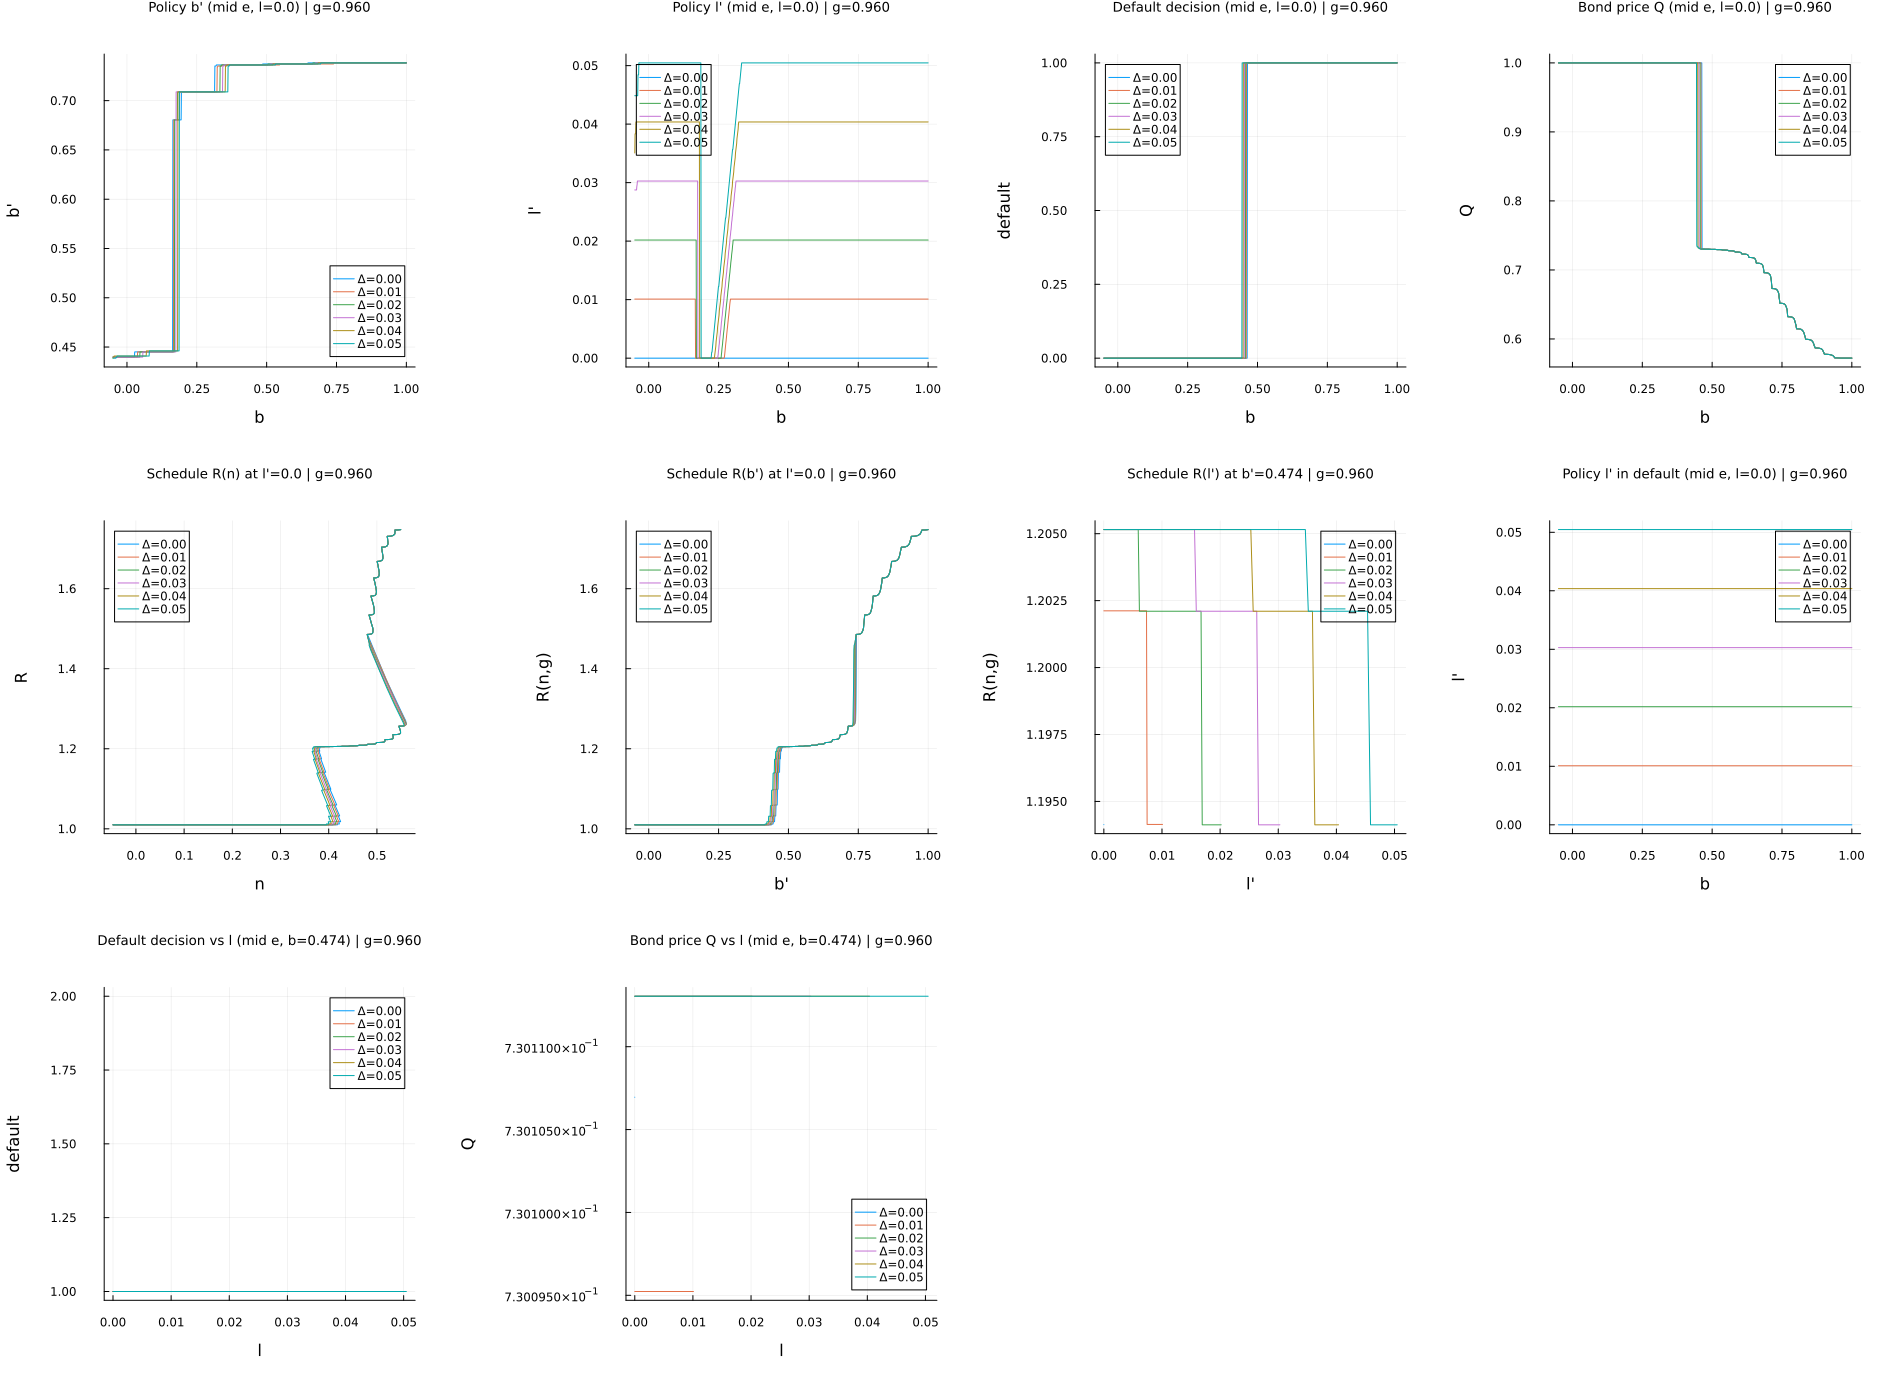

In [43]:
using Printf, Plots, Measures

include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))


results_dir = joinpath(pwd(), "results")

# Fix g index and compare across Δ at a given spread (all Δ on same plots)
spr = 0.06
Δ_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]
fixed_g_idx = 1  # 1 = low, 2 = high

# Load all available solutions for this spread
sols = NamedTuple[]
for Δ in Δ_vals
    fname = @sprintf("sol_Delta=%0.2f_spread=%0.2f.jld2", Δ, spr)
    fpath = joinpath(results_dir, fname)
    if !isfile(fpath)
        @warn "missing result file, skipping" fpath
        continue
    end
    data = load_jld2_file(fpath)
    push!(sols, (Δ = Δ, model = data.model, sol = data.sol))
end

if isempty(sols)
    error("No LOLR solutions found for spread=$(spr).")
end

# Use the first model to set indexes and labels
model0 = sols[1].model
b = model0.b
l = model0.l
g = model0.g

e_idx = Int(cld(model0.Ne, 2))
l_idx = 1
lp_idx = l_idx
b_idx = Int(cld(model0.Nb, 2))

l_val = round(l[l_idx], digits = 3)
lp_val = round(l[lp_idx], digits = 3)
bp_val = round(b[b_idx], digits = 3)

g_label = @sprintf("g=%0.3f", g[fixed_g_idx])

p1 = plot(title = "Policy b' (mid e, l=$(l_val)) | $(g_label)", titlefontsize = 9, xlabel = "b", ylabel = "b'")
p2 = plot(title = "Policy l' (mid e, l=$(l_val)) | $(g_label)", titlefontsize = 9, xlabel = "b", ylabel = "l'")
p3 = plot(title = "Default decision (mid e, l=$(l_val)) | $(g_label)", titlefontsize = 9, xlabel = "b", ylabel = "default")
p4 = plot(title = "Bond price Q (mid e, l=$(l_val)) | $(g_label)", titlefontsize = 9, xlabel = "b", ylabel = "Q")
p5 = plot(title = "Schedule R(n) at l'=$(lp_val) | $(g_label)", titlefontsize = 9, xlabel = "n", ylabel = "R")
p6 = plot(title = "Schedule R(b') at l'=$(lp_val) | $(g_label)", titlefontsize = 9, xlabel = "b'", ylabel = "R(n,g)")
p7 = plot(title = "Schedule R(l') at b'=$(bp_val) | $(g_label)", titlefontsize = 9, xlabel = "l'", ylabel = "R(n,g)")
p8 = plot(title = "Policy l' in default (mid e, l=$(l_val)) | $(g_label)", titlefontsize = 9, xlabel = "b", ylabel = "l'")
p9 = plot(title = "Default decision vs l (mid e, b=$(bp_val)) | $(g_label)", titlefontsize = 9, xlabel = "l", ylabel = "default")
p10 = plot(title = "Bond price Q vs l (mid e, b=$(bp_val)) | $(g_label)", titlefontsize = 9, xlabel = "l", ylabel = "Q")

for p in (p1, p2, p3, p4, p5, p6, p7, p8, p9, p10)
    plot!(p, background_color_legend = :transparent)
end

for item in sols
    Δ = item.Δ
    model = item.model
    sol = item.sol
    label = @sprintf("Δ=%0.2f", Δ)

    bprime_policy = model.b[sol.b_policy_idx[:, l_idx, fixed_g_idx, e_idx]]
    lprime_policy = model.l[sol.l_policy_idx[:, l_idx, fixed_g_idx, e_idx]]
    lprime_policy_d = model.l[sol.l_policy_idx_d[:, l_idx, fixed_g_idx, e_idx]]

    plot!(p1, model.b, bprime_policy, label = label)
    plot!(p2, model.b, lprime_policy, label = label)
    plot!(p3, model.b, Float64.(sol.d[:, l_idx, fixed_g_idx, e_idx]), label = label)
    plot!(p4, model.b, sol.Q[:, l_idx, fixed_g_idx, e_idx], label = label)
    plot!(p5, sol.n[:, lp_idx, fixed_g_idx], sol.R[:, lp_idx, fixed_g_idx], label = label)
    plot!(p6, model.b, sol.R[:, lp_idx, fixed_g_idx], label = label)
    plot!(p7, model.l, sol.R[b_idx, :, fixed_g_idx], label = label)
    plot!(p8, model.b, lprime_policy_d, label = label)
    plot!(p9, model.l, Float64.(sol.d[b_idx, :, fixed_g_idx, e_idx]), label = label)
    plot!(p10, model.l, sol.Q[b_idx, :, fixed_g_idx, e_idx], label = label)
end

fig = plot(p1, p2, p3, p4, p5, p6, p7, p8, p9, p10,
    layout = (3, 4), size = (1900, 1400),
    left_margin = 8mm, right_margin = 8mm, top_margin = 8mm, bottom_margin = 12mm)

fig_name = @sprintf("lolr_policies_by_delta_spread=%0.2f_gidx=%d.png", spr, fixed_g_idx)
fig_path = joinpath(results_dir, fig_name)
savefig(fig, fig_path)
println("Saved figure: ", fig_path)
fig


In [ ]:
# LaTeX table by Δ at fixed spread = 0.06 (same structure as main_s table)

using Printf, Statistics
include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))

function format_num(x)
    return isnan(x) ? "" : @sprintf("%.4f", x)
end

@inline _safe_mean(x, mask) = any(mask) ? mean(x[mask]) : NaN
@inline _safe_rate(numer, denom) = denom > 0 ? numer / denom : NaN

function _episode_starts(default_path::AbstractVector{Bool}; prev_default::Bool = false)
    starts = falses(length(default_path))
    prev = prev_default
    for t in eachindex(default_path)
        starts[t] = default_path[t] && !prev
        prev = default_path[t]
    end
    return starts
end

function summarize_simulation_for_table(sim, model::Model, sol::Solution; burnin::Int = 1_000)
    T = length(sim.b)
    @assert 0 <= burnin < T
    idx = (burnin + 1):T

    default_sample = sim.default[idx]
    b_sample = sim.b[idx]
    l_sample = sim.l[idx]
    y_sample = sim.y[idx]
    n_sample = sim.n[idx]
    n_l_sample = sim.n_l[idx]
    R_sample = sim.R[idx]
    g_idx_sample = sim.g_idx[idx]
    eps_idx_sample = sim.eps_idx[idx]

    prev_default = burnin == 0 ? false : sim.default[burnin]
    starts = _episode_starts(default_sample; prev_default = prev_default)
    default_rate = sum(starts) / length(default_sample)

    low_state = g_idx_sample .== argmin(model.g)
    high_state = g_idx_sample .== argmax(model.g)
    default_rate_low = _safe_rate(sum(starts .& low_state), sum(low_state))
    default_rate_high = _safe_rate(sum(starts .& high_state), sum(high_state))

    nondefault = .!default_sample
    spread = R_sample .- (1 + model.rstar)

    b_idx_sample = nearest_index(model.b, b_sample)
    l_idx_sample = nearest_index(model.l, l_sample)
    bprime_idx = similar(b_idx_sample)
    @inbounds for t in eachindex(b_idx_sample)
        bprime_idx[t] = sol.b_policy_idx[b_idx_sample[t], l_idx_sample[t], g_idx_sample[t], eps_idx_sample[t]]
    end

    f_sample = model.g[g_idx_sample] .* model.b[bprime_idx]
    qb_sample = f_sample ./ R_sample
    tb_sample = b_sample .+ l_sample .- n_sample .- n_l_sample

    qb_to_y = qb_sample ./ y_sample
    f_to_y = f_sample ./ y_sample
    n_to_y = n_sample ./ y_sample
    b_to_y = b_sample ./ y_sample
    tb_to_y = tb_sample ./ y_sample

    all_mask = nondefault
    low_mask = nondefault .& low_state
    high_mask = nondefault .& high_state

    function _moment_block(mask, this_default_rate)
        spread_valid = mask .& .!isnan.(spread) .& .!isinf.(spread)
        return (
            avg_spread = _safe_mean(spread, spread_valid),
            avg_qb_to_y = _safe_mean(qb_to_y, mask),
            avg_f_to_y = _safe_mean(f_to_y, mask),
            avg_n_to_y = _safe_mean(n_to_y, mask),
            avg_b_to_y = _safe_mean(b_to_y, mask),
            avg_tb_to_y = _safe_mean(tb_to_y, mask),
            default_rate = this_default_rate,
        )
    end

    return (
        all = _moment_block(all_mask, default_rate),
        low = _moment_block(low_mask, default_rate_low),
        high = _moment_block(high_mask, default_rate_high),
    )
end

function build_latex_table_by_delta(moments_by_delta::Dict{Float64, Any}; spread::Float64)
    blocks = [
        ("First moments", :all),
        ("Low-growth state", :low),
        ("High-growth state", :high),
    ]
    stats = [
        ("avg(spread)", :avg_spread),
        ("avg(qb/y)", :avg_qb_to_y),
        ("avg(f/y)", :avg_f_to_y),
        ("avg(n/y)", :avg_n_to_y),
        ("avg(b/y)", :avg_b_to_y),
        ("avg(tb/y)", :avg_tb_to_y),
        ("default rate", :default_rate),
    ]

    Δ_order = sort(collect(keys(moments_by_delta)))
    row_end = repeat("\\", 2)
    colspec = "l" * repeat("c", length(Δ_order))

    lines = String[]
    push!(lines, "\\begin{table}[!htbp]")
    push!(lines, "\\centering")
    push!(lines, @sprintf("\\caption{LOLR moments across \\(\\Delta\\) at fixed spread = %0.2f}", spread))
    push!(lines, "\\begin{tabular}{" * colspec * "}")
    push!(lines, "\\hline")

    header = "Moment"
    for Δ in Δ_order
        header *= " & " * @sprintf("\\(\\Delta\\)=%0.2f", Δ)
    end
    push!(lines, header * " " * row_end)
    push!(lines, "\\hline")

    for (block_label, block_key) in blocks
        push!(lines, "\\multicolumn{" * string(length(Δ_order) + 1) * "}{l}{\\textit{" * block_label * "}} " * row_end)
        for (stat_label, stat_key) in stats
            vals = [format_num(getfield(getfield(moments_by_delta[Δ], block_key), stat_key)) for Δ in Δ_order]
            push!(lines, stat_label * " & " * join(vals, " & ") * " " * row_end)
        end
        push!(lines, "\\hline")
    end

    push!(lines, "\\end{tabular}")
    push!(lines, "\\end{table}")

    return join(lines, "\n")
end

function run_lolr_delta_table(; spread::Float64 = 0.06, Δ_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05], T::Int = 20_000, burnin::Int = 1_000, seed::Int = 1234)
    results_dir = joinpath(pwd(), "results")
    mkpath(results_dir)

    moments_by_delta = Dict{Float64, Any}()

    for Δ in Δ_vals
        fname = @sprintf("sol_Delta=%0.2f_spread=%0.2f.jld2", Δ, spread)
        fpath = joinpath(results_dir, fname)
        if !isfile(fpath)
            @warn "missing result file, skipping" fpath
            continue
        end

        loaded = load_jld2_file(fpath)
        if loaded.model === nothing || loaded.sol === nothing
            @warn "result file missing model/sol payload, skipping" fpath
            continue
        end
        model = loaded.model
        sol = loaded.sol

        b0_idx = findmin(abs.(model.b))[2]
        l0_idx = findmin(abs.(model.l))[2]
        sim = simulate(model, sol; T = T, b0_idx = b0_idx, l0_idx = l0_idx, seed = seed)

        moments_by_delta[Δ] = summarize_simulation_for_table(sim, model, sol; burnin = burnin)
        println("Computed moments for Δ=", Δ, " at spread=", spread)
    end

    if isempty(moments_by_delta)
        error("No LOLR solutions found for spread=$(spread).")
    end

    latex_table = build_latex_table_by_delta(moments_by_delta; spread = spread)
    tex_path = joinpath(results_dir, @sprintf("lolr_moments_delta_spread=%0.2f.tex", spread))
    open(tex_path, "w") do io
        write(io, latex_table)
    end

    println("Saved LaTeX table to: ", tex_path)
    println(latex_table)

    return (moments_by_delta = moments_by_delta, tex_path = tex_path, latex_table = latex_table)
end

run_lolr_delta_table()
